# 📊 Esercitazione Python: Analisi Dati Sindaci
## VERSIONE STUDENTE

---

### 🎯 Obiettivi dell'Esercitazione

In questa esercitazione imparerai a:
1. Importare e manipolare dati da file Excel con Pandas
2. Calcolare statistiche descrittive
3. Creare nuove colonne calcolate
4. Gestire valori mancanti
5. Filtrare e raggruppare dati

---

### 📋 Istruzioni Generali

- Leggi attentamente ogni esercizio prima di iniziare
- Completa il codice nelle celle contrassegnate con `# IL TUO CODICE QUI`
- Esegui le celle in ordine sequenziale
- Controlla sempre l'output per verificare la correttezza

## 📦 PARTE 1: Setup e Import delle Librerie

**Obiettivo**: Importare le librerie necessarie per l'analisi

**Istruzioni**:
1. Importa pandas con alias `pd`
2. Importa numpy con alias `np`
3. Importa datetime

In [37]:
# IL TUO CODICE QUI
# Importa le librerie necessarie
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt




print("✅ Librerie importate con successo!")

✅ Librerie importate con successo!


## 📂 PARTE 2: Caricamento e Esplorazione Iniziale

**Obiettivo**: Caricare il dataset e comprenderne la struttura

**Istruzioni**:
1. Carica il file 'Sindaci_Enhanced_1_.xlsx', foglio 'Dati Sindaci' in un DataFrame chiamato `df`
2. Stampa il numero di righe e colonne
3. Visualizza le prime 5 righe

In [38]:
# IL TUO CODICE QUI
# Carica il dataset

df=pd.read_excel("Sindaci.xlsx")

print("Il numero di righe del database è ", df.shape[0])
print("Il numero di colonne del database è ", df.shape[1])

display(df.head())


Il numero di righe del database è  31466
Il numero di colonne del database è  6


,Nome Cognome,COMUNE,sesso,data_nascita,luogo_nascita,descrizione_carica
0,LORENZO GIUSEPPE LUCCHINI,ACQUI TERME,M,1963-08-18,NITO,Sindaco
1,PAOLO DOMENICO MIGHETTI,ACQUI TERME,M,1979-07-08,(AL),Vicesindaco
2,CINZIA MONTELLI,ACQUI TERME,F,1967-10-19,(AL),Assessore
3,LORENZA OSELIN,ACQUI TERME,F,1959-03-01,(VR),Assessore
4,GIOVANNI PIETRO ROLANDO,ACQUI TERME,M,1968-06-07,(AL),Assessore


**Istruzioni**:
1. Usa `.info()` per visualizzare informazioni sul dataset
2. Usa `.describe()` per le statistiche descrittive

In [39]:
# IL TUO CODICE QUI
# Informazioni e statistiche sul dataset

print("Informazioni sul database")
df.info()

print("\nDescrizione più accurata del database")
df.describe()

Informazioni sul database
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31466 entries, 0 to 31465
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Nome Cognome        31466 non-null  object        
 1   COMUNE              31466 non-null  object        
 2   sesso               31466 non-null  object        
 3   data_nascita        31466 non-null  datetime64[ns]
 4   luogo_nascita       31463 non-null  object        
 5   descrizione_carica  31466 non-null  object        
dtypes: datetime64[ns](1), object(5)
memory usage: 1.4+ MB

Descrizione più accurata del database


,data_nascita
count,31466
mean,1972-01-13 07:30:32.606623024
min,1932-06-08 00:00:00
25%,1963-04-01 00:00:00
50%,1972-05-23 12:00:00
75%,1980-11-23 00:00:00
max,2003-08-18 00:00:00


## 🔍 PARTE 3: Analisi dei Valori Mancanti

**Obiettivo**: Identificare e quantificare i dati mancanti

**Istruzioni**:
1. Crea un DataFrame con:
   - Colonna 'Valori Mancanti': numero di valori nulli per colonna
   - Colonna 'Percentuale (%)': percentuale di valori nulli
2. Ordina per numero di valori mancanti (decrescente)
3. Visualizza solo le colonne con valori mancanti > 0

In [40]:
# IL TUO CODICE QUI
# Analisi valori mancanti


df_mancanze=pd.DataFrame({
    "Valori_Mancanti": df.isnull().sum(),
    "Percentuale": (df.isnull().sum()/len(df))*100
    })

df_mancanze.sort_values("Valori_Mancanti", ascending=False, inplace=True)

display(df_mancanze)

print("\nLe uniche colonne che possiedono dati mancanti sono: ")
absent=df_mancanze.loc[df_mancanze["Valori_Mancanti"]>0]
display(absent)


,Valori_Mancanti,Percentuale
luogo_nascita,3,0.009534
Nome Cognome,0,0.000000
COMUNE,0,0.000000
sesso,0,0.000000
data_nascita,0,0.000000
descrizione_carica,0,0.000000



Le uniche colonne che possiedono dati mancanti sono: 


,Valori_Mancanti,Percentuale
luogo_nascita,3,0.009534


**Istruzioni**:
Crea un grafico a barre orizzontali che mostri la percentuale di valori mancanti per colonna

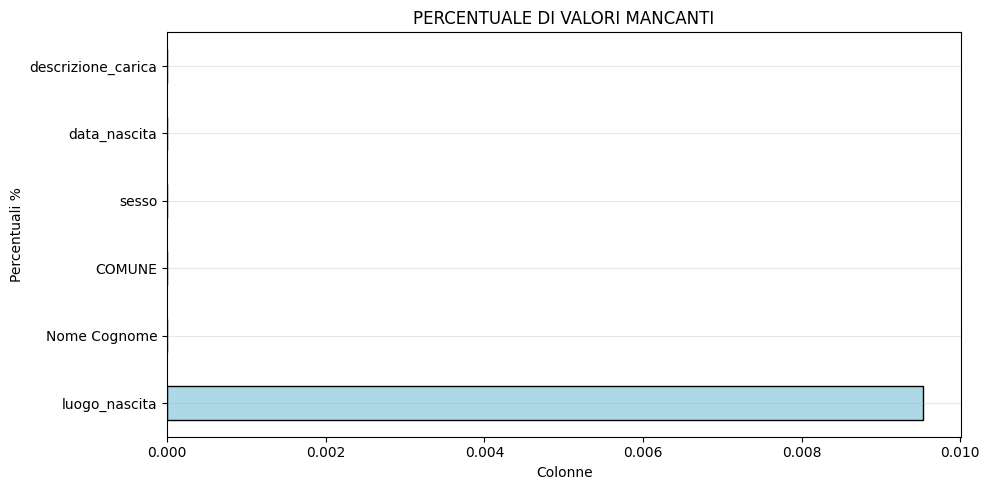

In [41]:
# IL TUO CODICE QUI
# Visualizzazione grafica dei valori mancanti

plt.figure(figsize=(10,5))
df_mancanze["Percentuale"].plot(kind="barh", color="lightblue", edgecolor="black")
plt.title("PERCENTUALE DI VALORI MANCANTI")
plt.xlabel("Colonne")
plt.ylabel("Percentuali %")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 🧮 PARTE 4: Creazione di Nuove Colonne Calcolate

**Obiettivo**: Creare colonne derivate per arricchire l'analisi

### Esercizio 4.1: Estrazione del Cognome

**Istruzioni**:
1. Dalla colonna 'Nome Cognome', estrai l'ultima parola (il cognome)
2. Crea una nuova colonna chiamata 'cognome'
3. Suggerimento: usa `.str.split().str[-1]`

In [42]:
# IL TUO CODICE QUI
# Estrai il cognome

df["Cognome"]=df["Nome Cognome"].str.split().str[-1]
display(df)



,Nome Cognome,COMUNE,sesso,data_nascita,luogo_nascita,descrizione_carica,Cognome
0,LORENZO GIUSEPPE LUCCHINI,ACQUI TERME,M,1963-08-18,NITO,Sindaco,LUCCHINI
1,PAOLO DOMENICO MIGHETTI,ACQUI TERME,M,1979-07-08,(AL),Vicesindaco,MIGHETTI
2,CINZIA MONTELLI,ACQUI TERME,F,1967-10-19,(AL),Assessore,MONTELLI
3,LORENZA OSELIN,ACQUI TERME,F,1959-03-01,(VR),Assessore,OSELIN
4,GIOVANNI PIETRO ROLANDO,ACQUI TERME,M,1968-06-07,(AL),Assessore,ROLANDO
...,...,...,...,...,...,...,...
31461,STEFANIA VALDES,VILLASOR,F,1977-10-18,(CA),Assessore,VALDES
31462,FRANCESCA ZORCO,VILLASOR,F,1985-08-14,(CA),Assessore,ZORCO
31463,GIANLUCA MELIS,VILLASPECIOSA,M,1972-08-05,(CA),Sindaco,MELIS
31464,ANDREA GALLUS,VILLASPECIOSA,M,1974-12-06,(CA),Assessore,GALLUS


### Esercizio 4.2: Calcolo dell'Età Precisa

**Istruzioni**:
1. Crea una funzione `calcola_eta(data_nascita)` che:
   - Restituisce `np.nan` se la data è nulla
   - Calcola l'età tenendo conto di mese e giorno
2. Applica la funzione alla colonna 'data_nascita'
3. Salva il risultato in una nuova colonna 'eta_precisa'

In [43]:
# IL TUO CODICE QUI
from datetime import date

def calcola_eta(data_nascita):
    # Completa la funzione
    try:
        oggi=date.today()
        if (oggi.month, oggi.day) >= (data_nascita.month, data_nascita.day):
            eta=int(oggi.year)-int(data_nascita.year)
        else:
            eta=int(oggi.year)-int(data_nascita.year)-1
        return eta
    except ValueError:
         return np.nan

# Applica la funzione

df["eta_precisa"]=df["data_nascita"].apply(calcola_eta)
display(df)



,Nome Cognome,COMUNE,sesso,data_nascita,luogo_nascita,descrizione_carica,Cognome,eta_precisa
0,LORENZO GIUSEPPE LUCCHINI,ACQUI TERME,M,1963-08-18,NITO,Sindaco,LUCCHINI,62
1,PAOLO DOMENICO MIGHETTI,ACQUI TERME,M,1979-07-08,(AL),Vicesindaco,MIGHETTI,46
2,CINZIA MONTELLI,ACQUI TERME,F,1967-10-19,(AL),Assessore,MONTELLI,58
3,LORENZA OSELIN,ACQUI TERME,F,1959-03-01,(VR),Assessore,OSELIN,66
4,GIOVANNI PIETRO ROLANDO,ACQUI TERME,M,1968-06-07,(AL),Assessore,ROLANDO,57
...,...,...,...,...,...,...,...,...
31461,STEFANIA VALDES,VILLASOR,F,1977-10-18,(CA),Assessore,VALDES,48
31462,FRANCESCA ZORCO,VILLASOR,F,1985-08-14,(CA),Assessore,ZORCO,40
31463,GIANLUCA MELIS,VILLASPECIOSA,M,1972-08-05,(CA),Sindaco,MELIS,53
31464,ANDREA GALLUS,VILLASPECIOSA,M,1974-12-06,(CA),Assessore,GALLUS,51


### Esercizio 4.3: Classificazione Generazionale

**Istruzioni**:
1. Crea una funzione `classifica_generazione(data_nascita)` con queste regole:
   - < 1946: 'Silent Generation'
   - 1946-1964: 'Baby Boomers'
   - 1965-1980: 'Generazione X'
   - 1981-1996: 'Millennials'
   - >= 1997: 'Generazione Z'
2. Applica la funzione e crea la colonna 'generazione'
3. Visualizza la distribuzione con un grafico a barre

,Nome Cognome,COMUNE,sesso,data_nascita,luogo_nascita,descrizione_carica,Cognome,eta_precisa,generazione
0,LORENZO GIUSEPPE LUCCHINI,ACQUI TERME,M,1963-08-18,NITO,Sindaco,LUCCHINI,62,Baby Boomers
1,PAOLO DOMENICO MIGHETTI,ACQUI TERME,M,1979-07-08,(AL),Vicesindaco,MIGHETTI,46,Generazione X
2,CINZIA MONTELLI,ACQUI TERME,F,1967-10-19,(AL),Assessore,MONTELLI,58,Generazione X
3,LORENZA OSELIN,ACQUI TERME,F,1959-03-01,(VR),Assessore,OSELIN,66,Baby Boomers
4,GIOVANNI PIETRO ROLANDO,ACQUI TERME,M,1968-06-07,(AL),Assessore,ROLANDO,57,Generazione X
...,...,...,...,...,...,...,...,...,...
31461,STEFANIA VALDES,VILLASOR,F,1977-10-18,(CA),Assessore,VALDES,48,Generazione X
31462,FRANCESCA ZORCO,VILLASOR,F,1985-08-14,(CA),Assessore,ZORCO,40,Millenials
31463,GIANLUCA MELIS,VILLASPECIOSA,M,1972-08-05,(CA),Sindaco,MELIS,53,Generazione X
31464,ANDREA GALLUS,VILLASPECIOSA,M,1974-12-06,(CA),Assessore,GALLUS,51,Generazione X


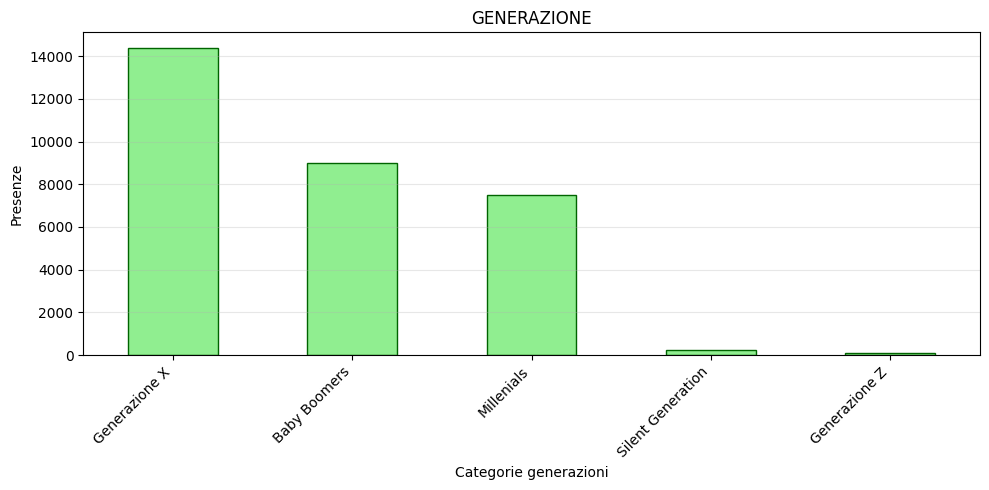

In [44]:
# IL TUO CODICE QUI
def classifica_generazione(data_nascita):
    # Completa la funzione
    try:
        if(data_nascita.year<1946):
            return "Silent Generation"
        elif(data_nascita.year>=1946 and data_nascita.year<=1964):
            return "Baby Boomers"
        elif(data_nascita.year>=1965 and data_nascita.year<=1980):
            return "Generazione X"
        elif(data_nascita.year>=1981 and data_nascita.year<=1996):
            return "Millenials"
        elif(data_nascita.year==1997):
            return "Generazione Z"
    except ValueError:
        return np.nan

# Applica la funzione

df["generazione"]=df["data_nascita"].apply(classifica_generazione)
display(df)

# Crea il grafico

plt.figure(figsize=(10,5))
df["generazione"].value_counts().plot(kind="bar", color="lightgreen", edgecolor="darkgreen")
plt.title("GENERAZIONE")
plt.xlabel("Categorie generazioni")
plt.ylabel("Presenze")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 📊 PARTE 5: Analisi Statistiche

### Esercizio 5.1: Distribuzione per Genere

**Istruzioni**:
1. Calcola il conteggio per genere usando `value_counts()`
2. Calcola la percentuale per genere
3. Crea un DataFrame con entrambe le informazioni
4. Visualizza con un grafico a torta

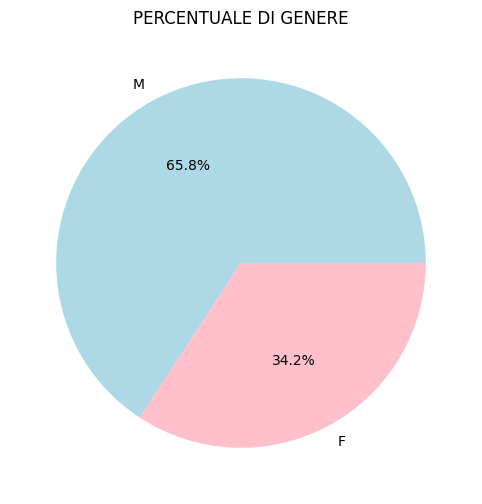

In [45]:
# IL TUO CODICE QUI
# Analisi distribuzione per genere
gens=df["sesso"].value_counts()
gens_percent=(df["sesso"].value_counts()/len(df))*100

df_genere=pd.DataFrame({
    "genere":gens,
    "genere_percent":gens_percent
})

# Grafico a torta

plt.figure(figsize=(12,6))
df_genere["genere_percent"].plot(kind="pie", colors=["lightblue", "pink"],autopct="%1.1f%%")
plt.title("PERCENTUALE DI GENERE")
plt.ylabel("")
plt.show()



### Esercizio 5.2: Statistiche sull'Età per Genere

**Istruzioni**:
1. Usa `groupby()` per raggruppare per genere
2. Calcola media, mediana, min, max e deviazione standard dell'età
3. Crea un boxplot per visualizzare la distribuzione

,Media,Mediana,Min,Max,Dev_standard
sesso,,,,,
F,50.889673,51.0,22,89,11.167506
M,55.001353,55.0,22,93,12.218221


<Figure size 1000x500 with 0 Axes>

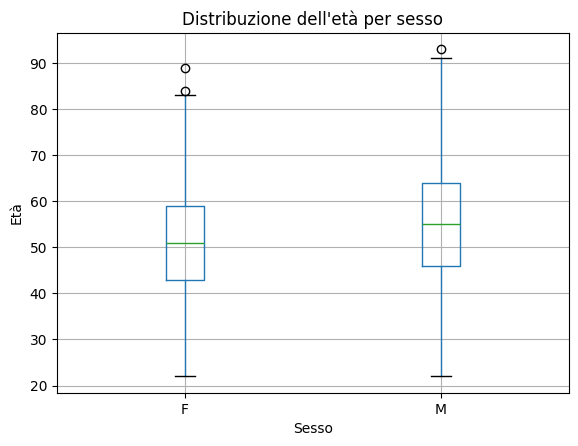

In [46]:
# IL TUO CODICE QUI
# Statistiche età per genere

#df_orded=df.sort_values("eta_precisa").copy()

df_genere1=df.groupby("sesso").agg(
    Media=("eta_precisa", "mean"),
    Mediana=("eta_precisa", "median"),
    Min=("eta_precisa", "min"),
    Max=("eta_precisa", "max"),
    Dev_standard=("eta_precisa", "std")
)

display(df_genere1)

# Boxplot

plt.figure(figsize=(10,5))

df.boxplot(column="eta_precisa", by="sesso")

plt.title("Distribuzione dell'età per sesso")
plt.suptitle("")
plt.xlabel("Sesso")
plt.ylabel("Età")
plt.show()


### Esercizio 5.3: Top 10 Comuni per Numero di Sindaci

**Istruzioni**:
1. Conta quanti sindaci ci sono per ogni comune
2. Seleziona i primi 10
3. Visualizza con un grafico a barre orizzontali

,COMUNE,Totale
0,LIVO,2
1,PEGLIO,2
2,CASTRO,2
3,SAMONE,2
4,SAN TEODORO,2
5,ALLUVIONI PIOVERA,1
6,ALTAVILLA MONFERRATO,1
7,ALZANO SCRIVIA,1
8,SENORBI',1
9,BRIGNANO FRASCATA,1


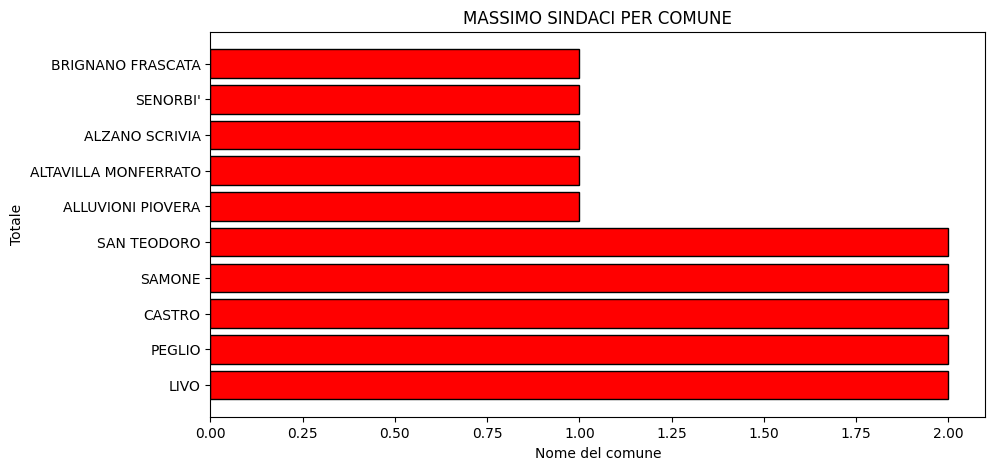

In [47]:
# IL TUO CODICE QUI
# Top 10 comuni

max_sindaci = (
    df[df["descrizione_carica"] == "Sindaco"]["COMUNE"].value_counts()
    .reset_index(name="Totale").sort_values("Totale", ascending=False).head(10)                                 
)
display(max_sindaci)
# Grafico a barre

plt.figure(figsize=(10,5))
plt.barh(max_sindaci["COMUNE"], max_sindaci["Totale"], color="red", edgecolor="black")
plt.title("MASSIMO SINDACI PER COMUNE")
plt.xlabel("Nome del comune")
plt.ylabel("Totale")
plt.show()


## 🔎 PARTE 6: Filtering e Query Avanzate

### Esercizio 6.1: Sindaci Giovani (età < 40 anni)

**Istruzioni**:
1. Filtra il DataFrame per età < 40
2. Conta quanti sono
3. Visualizza nome, comune, genere ed età ordinati per età

In [48]:
# IL TUO CODICE QUI
# Filtra sindaci giovani

df_giovani=df.query("eta_precisa < 40").sort_values("eta_precisa", ascending=False)
conteggio=df_giovani.shape[0]
print(f"Il numero di persone che hanno meno di 40 anni sono: {conteggio}\n")
display(df_giovani[["Nome Cognome", "COMUNE", "sesso", "eta_precisa"]])



Il numero di persone che hanno meno di 40 anni sono: 4178



,Nome Cognome,COMUNE,sesso,eta_precisa
31373,FRANCESCO CASULA,SIURGUS DONIGALA,M,39
31351,DANILO PORCU,SEUI,M,39
9818,ANDREA ESPOSITO,BERNAREGGIO,M,39
9821,STEFANO CRIPPA,BERNAREGGIO,M,39
9841,ANTONELLA CASATI,BRIOSCO,F,39
...,...,...,...,...
26106,FABIANA D'ADAMO,ALBANO DI LUCANIA,F,23
3918,PEDRO FILIPPO DEL,TRASQUERA,M,23
175,GAIA BREGLIA,CASTELNUOVO SCRIVIA,F,22
20949,SARA OLIVA,RONCIGLIONE,F,22


In [49]:
# IL TUO CODICE QUI
# Filtra donne con carica prioritaria

df_donne=df.query('sesso == "F" and (descrizione_carica == "Sindaco" or descrizione_carica == "Vicesindaco")')
display(df_donne)



,Nome Cognome,COMUNE,sesso,data_nascita,luogo_nascita,descrizione_carica,Cognome,eta_precisa,generazione
7,GIOVANNA GAZZOLI,ALBERA LIGURE,F,1950-02-27,(AL),Vicesindaco,GAZZOLI,75,Baby Boomers
10,MARIA ENRICA BARRERA,ALESSANDRIA,F,1963-03-30,(AL),Vicesindaco,BARRERA,62,Baby Boomers
19,SABRINA ZEGLIO,ALFIANO NATTA,F,1971-03-31,(TO),Sindaco,ZEGLIO,54,Generazione X
20,GIOVANNA MORRA,ALFIANO NATTA,F,1963-03-31,(AL),Vicesindaco,MORRA,62,Baby Boomers
26,MARTA CLARA GILARDENGHI,ALLUVIONI PIOVERA,F,1951-08-22,(AL),Vicesindaco,GILARDENGHI,74,Baby Boomers
...,...,...,...,...,...,...,...,...,...
31357,CARMELA PILO,SIDDI,F,1955-07-06,(NU),Vicesindaco,PILO,70,Baby Boomers
31360,FRANCESCA ATZORI,SILIQUA,F,1980-10-26,(CA),Sindaco,ATZORI,45,Generazione X
31404,MARIROSA CONTINI,USSANA,F,1960-04-25,(CA),Vicesindaco,CONTINI,65,Baby Boomers
31423,DEBORA PORRA',VILLAMASSARGIA,F,1983-07-31,(GE),Sindaco,PORRA',42,Millenials


### Esercizio 6.3: Raggruppamento per Provincia di Nascita

**Istruzioni**:
1. Raggruppa per provincia di nascita
2. Calcola: numero di sindaci, età media, età min, età max
3. Ordina per numero di sindaci (decrescente)
4. Visualizza le prime 10 province

In [50]:
# IL TUO CODICE QUI
# Statistiche per provincia

df_luogo_nascita = (
    df[df["descrizione_carica"] == "Sindaco"].groupby("luogo_nascita").agg(
          Numero_sindaci=("descrizione_carica", "count"),
          eta_media=("eta_precisa", "mean"),
          eta_max=("eta_precisa", "max"),
          eta_min=("eta_precisa", "min")
      )
      .reset_index()
)

display(df_luogo_nascita)

,luogo_nascita,Numero_sindaci,eta_media,eta_max,eta_min
0,(AG),38,57.500000,78,34
1,(AL),173,60.965318,87,33
2,(AN),48,59.500000,78,40
3,(AO),66,53.878788,78,31
4,(AP),72,56.986111,80,37
...,...,...,...,...,...
114,SILE,1,37.000000,37,37
115,TINA,3,69.666667,74,64
116,TRIA,1,61.000000,61,61
117,UELA,5,63.600000,67,60


### Esercizio 7: Heatmap Correlazioni

**Istruzioni**:
1. Seleziona solo le colonne numeriche
2. Calcola la matrice di correlazione

In [51]:
# IL TUO CODICE QUI
# Heatmap correlazioni





## 🎓 PARTE 8: Esportazione dei Risultati

### Esercizio 8.1: Creazione Report Statistico

**Istruzioni**:
1. Crea un dizionario con i seguenti indicatori:
   - Totale Sindaci
   - Percentuale Donne e Uomini
   - Età Media, Mediana, Min, Max
   - Numero sindaci < 40 anni
   - Numero sindaci >= 60 anni
   - Numero comuni e province
2. Converti in DataFrame e visualizza

In [52]:
# IL TUO CODICE QUI
# Crea report statistico



diz={
    "Totale_Sindaci": len(df.query('descrizione_carica=="Sindaco"')),
    "Percentuale_Donne": (len(df.query('sesso=="F"'))/len(df)*100),
    "Percentuale_Uomini": (len(df.query('sesso=="M"'))/len(df)*100),
    "Eta_Media": df["eta_precisa"].mean(),
    "Eta_Mediana": df["eta_precisa"].median(),
    "Eta_min": df["eta_precisa"].min(),
    "Eta_max": df["eta_precisa"].max(),
    "Numero_Sindaci_giovani": len(df.query('eta_precisa<40 and descrizione_carica=="Sindaco"')),
    "Numero_Sindaci_vecchi": len(df.query('eta_precisa>60 and descrizione_carica=="Sindaco"')),
    "Numero_Comuni": df["COMUNE"].nunique(),
    "Numero_Province": df["luogo_nascita"].nunique()
}

df_totale=pd.DataFrame(diz, index=[0])
display(df_totale)




,Totale_Sindaci,Percentuale_Donne,Percentuale_Uomini,Eta_Media,Eta_Mediana,Eta_min,Eta_max,Numero_Sindaci_giovani,Numero_Sindaci_vecchi,Numero_Comuni,Numero_Province
0,7773,34.221064,65.778936,53.594292,53.0,22,93,414,3045,7788,144


### Esercizio 8.2: Esportazione Dataset Arricchito

**Istruzioni**:
1. Esporta il DataFrame arricchito in un file Excel
2. Nome file: 'sindaci_analizzati.xlsx'
3. Nome foglio: 'Dati Completi'

In [55]:
# IL TUO CODICE QUI
# Esporta dataset

df_totale.to_excel("sindaci_analizzati.xlsx", sheet_name="Dati Completi", index=False)
